# Chronos-Bolt layer probing

## Setup

In [1120]:
import torch, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from chronos import BaseChronosPipeline
import pandas as pd
import json
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import tqdm
from sklearn.decomposition import PCA

sys.path.insert(0, "../data/synthetic/")         
import signalGenerator as sg   
from pandas import json_normalize

In [1121]:
# set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rngm = np.random.default_rng(SEED)

In [1122]:
pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-tiny", device_map="cpu")
model = pipeline.model
cfg = model.config.chronos_config
print(json.dumps(cfg, indent=4))

DEFAULT_PATCH_SIZE = cfg["input_patch_size"]
DEFAULT_STRIDE = cfg["input_patch_stride"]
PRED_LEN_DEFAULT = cfg["prediction_length"]
N_ENC = len(model.encoder.block)
N_DEC = len(model.decoder.block)
QUANTILES = cfg["quantiles"]

{
    "context_length": 2048,
    "input_patch_size": 16,
    "input_patch_stride": 16,
    "prediction_length": 64,
    "quantiles": [
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9
    ],
    "use_reg_token": true
}


In [1123]:
CONTEXT_LEN = 512
# We are using 512 as well as the paper, but we can experiment with different context lengths to see how it affects the results. 
pipeline.model.config.chronos_config["context_length"] = CONTEXT_LEN
cfg = pipeline.model.config.chronos_config
CONTEXT_LEN = cfg["context_length"]

In [1124]:
OUT = Path("../outputs/signals/")
existing = [d for d in OUT.iterdir() if d.is_dir() and d.name.startswith("signal_")]
if existing:
    i = max([int(d.name.split("_")[1]) for d in existing]) + 1
else:    
    i = 0
OUT = OUT/f"signal_{i}"
OUT.mkdir(parents=True, exist_ok=True)
print(f"Saving outputs to {OUT}")

Saving outputs to ../outputs/signals/signal_18


## 1 - Generate the probe signal here (named & saved)
Edit `json_config` → `inject` is a **list** of `{freq_hz, amplitude, phase}` dicts.

All injection is in **Hz** (absolute frequency). CPP is a **derived** quantity:

    cpp = freq_hz * P / fs

Structural aliasing blind spots occur when `cpp` is an integer, e.g.:
  - P=16, fs=256: f=64 Hz → cpp=4  (blind), f=80 Hz → cpp=5  (blind)
  - P=16, fs=256: f=120 Hz → cpp=7.5 (NOT blind)

Multiple tones can be injected simultaneously to test cross-frequency interactions.


In [1125]:
json_config = [
    {
        "generator": "kernelsynth",
        "n_realizations": 5,
        "seed": 15,
        "params": {
            "J": 5,
            "l_syn": 512,
            "fs": 256,
            "jitter": 0.0001,
            "P": 16,
            "inject": [
                {
                    "freq_hz": 64.0,
                    "amplitude": 0.001,
                    "phase": 0.0
                }
            ]
        }
    }
]

In [1126]:
# Example: TSMixup with two injected tones (one blind, one not)
# json_config = [
#     {
#         "generator": "tsmixup",
#         "n_realizations": 5,
#         "seed": 13,
#         "params": {
#             "K": 3,
#             "alpha": 1.5,
#             "l_min": CONTEXT_LEN,
#             "l_max": CONTEXT_LEN,
#             "fs": 256,
#             "P": 16,
#             "t_lengths": [256, 384, 512],
#             "inject": [
#                 {"freq_hz": 64.0,  "amplitude": 0.02, "phase": 0.0},
#                 {"freq_hz": 120.0, "amplitude": 0.02, "phase": 1.5707963}
#             ]
#         }
#     }
# ]


In [1127]:
if json_config[0]["generator"] == "kernelsynth":
    json_config[0]["params"]["l_syn"] = CONTEXT_LEN
    # the signal fed to the model is the first CONTEXT_LEN samples of the generated signal, 
    # which is the default context length of the model, and also the length of the generated signal (l_syn) to avoid having to crop it
    gen = sg.runKernelSynth(json_config[0]["params"], json_config[0]["seed"], output_dir=OUT)
    NAME = "kernelsynth"
else:
    json_config[0]["params"]["l_min"] = CONTEXT_LEN
    json_config[0]["params"]["l_max"] = CONTEXT_LEN
    gen = sg.runTSMixup(json_config[0]["params"], json_config[0]["seed"], output_dir=OUT)
    NAME = "tsmixup"

print(gen.getParameters())

{'generator': 'KernelSynth', 'J': 5, 'l_syn': 512, 'fs': 256, 'jitter': 0.0001, 'P': 16, 'inject': [{'freq_hz': 64.0, 'amplitude': 0.001, 'phase': 0.0, 'cpp': 4.0}]}


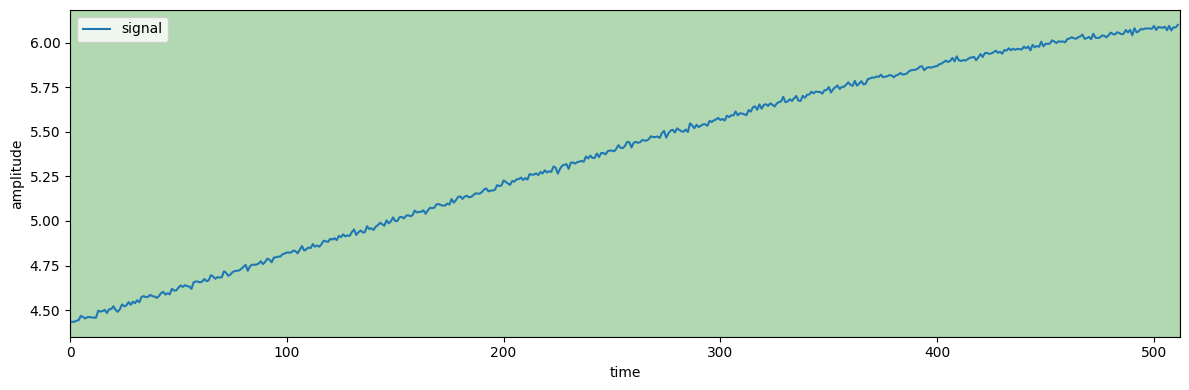

In [1128]:
signal = np.asarray(gen.generate(), float).ravel()
gen.save(signal)
with open(OUT/"config.json", "w") as f:
    json.dump(json_config, f, indent=4)
    
plt.figure(figsize=(12, 4))
plt.plot(signal, label="signal")
plt.axvspan(0, CONTEXT_LEN, color="green", alpha=0.3)
plt.xlabel("time")
plt.ylabel("amplitude")
plt.legend();
plt.xlim(0, len(signal));
plt.tight_layout()

plt.savefig(OUT/f"{NAME}.png", dpi=140, bbox_inches="tight") 
plt.show() 

In [1129]:
# Derive cpp for each injected tone (read-only; cpp is NOT a generation input).
# CRITICAL: use the model's actual patch size, not the one in the JSON config.
FS = json_config[0]['params']['fs']
P_json  = json_config[0]['params'].get('P', 16)
P_model = DEFAULT_PATCH_SIZE  # from cfg['input_patch_size']

if P_json != P_model:
    print(f"⚠ WARNING: signals.json declares P={P_json} but the model uses P={P_model}."
          f" Using P_model for cpp computation.")
P = P_model

inject_specs = json_config[0]['params'].get('inject', [])

# Tolerance for declaring a frequency to be on the integer-cpp grid.
# 1e-6 is essentially exact-match (limited by floating-point); use a larger
# value (e.g. 0.05) if you want a 'near-blind' band — but report which one
# you used in the writeup, since hypothesis (i) of the coursework is about
# EXACT phase-locking at integer cpp.
BLIND_TOL = 1e-6

INJECT_LIST = []
for c in inject_specs:
    freq_hz = float(c['freq_hz'])
    cpp     = freq_hz * P / FS
    INJECT_LIST.append({
        'freq_hz':   freq_hz,
        'amplitude': float(c.get('amplitude', 1.0)),
        'phase':     float(c.get('phase', 0.0)),
        'cpp':       cpp,
        'is_blind':  abs(cpp - round(cpp)) < BLIND_TOL,
        'cpp_dist':  abs(cpp - round(cpp)),  # distance to nearest integer cpp
    })

print(f'fs={FS} Hz, P={P}, blind tolerance={BLIND_TOL}')
for info in INJECT_LIST:
    blind = '⚠ BLIND SPOT' if info['is_blind'] else 'visible'
    print(f"  {info['freq_hz']:7.4f} Hz  →  cpp={info['cpp']:.6f}  "
          f"(dist={info['cpp_dist']:.2e})  {blind}")


fs=256 Hz, P=16, blind tolerance=1e-06
  64.0000 Hz  →  cpp=4.000000  (dist=0.00e+00)  ⚠ BLIND SPOT


## 2 - Capture every stage

In [1130]:
def cut(signal, stride=DEFAULT_STRIDE): 
    """
    Cuts the input signal into patches of size DEFAULT_PATCH_SIZE with stride stride.
    Returns a matrix of shape (num_patches, DEFAULT_PATCH_SIZE) where num_patches is the number of patches that can be extracted from x with the given DEFAULT_PATCH_SIZE and stride.
    """
    patches = []
    for i in range(0, len(signal)-DEFAULT_PATCH_SIZE+1, stride):
        patch = signal[i:i+DEFAULT_PATCH_SIZE]
        patches.append(patch)
    return np.stack(patches)

In [1131]:
def as_matrix(t):
    """
    Converts a tensor or a tuple of tensors to a numpy matrix. If the input is a tuple, it takes the first element.
    If the resulting array has 3 dimensions, it returns the first element along the first dimension, otherwise it returns the array as is.
    """
    if isinstance(t, tuple): t = t[0]
    a = t.detach().cpu().numpy(); return a[0] if a.ndim == 3 else a

In [1132]:
def forward_capture(context, stride=DEFAULT_STRIDE):
    """
    Feed the input context to the model and capture per-layer outputs.
    
    The cap dict keys are stage names; values are numpy matrices.
    The stride parameter sets model.patch.patch_stride for this call only
    and is ALWAYS restored on exit (try/finally), so this function is
    safe to call inside loops.
    """
    cap, handles = {}, []
    saved_stride = model.patch.patch_stride
    model.patch.patch_stride = stride

    def save(key, use_in=False):
        def hook(m, i, o):
            cap[key] = as_matrix(i[0] if use_in else o)
        return hook

    try:
        if hasattr(model, "instance_norm"):
            handles.append(model.instance_norm.register_forward_hook(save("scaled")))
        handles.append(model.patch.register_forward_hook(save("patched")))
        handles.append(model.input_patch_embedding.register_forward_hook(save("pre_embed", True)))
        handles.append(model.input_patch_embedding.register_forward_hook(save("post_embed")))
        for k, b in enumerate(model.encoder.block):
            handles.append(b.register_forward_hook(save(f"enc{k}")))
        for k, b in enumerate(model.decoder.block):
            handles.append(b.register_forward_hook(save(f"dec{k}")))
        if hasattr(model, "output_patch_embedding"):
            handles.append(model.output_patch_embedding.register_forward_hook(save("dec_out", True)))

        x = torch.tensor(np.asarray(context, np.float32)).unsqueeze(0)
        with torch.no_grad():
            fc = pipeline.predict(x, prediction_length=PRED_LEN_DEFAULT)

    finally:
        for h in handles:
            h.remove()
        model.patch.patch_stride = saved_stride

    # Build the input-side patches via the same patching scheme
    sc = cap.pop("scaled", None)
    cap = {
        "input":  cut(context, stride=stride),
        "scaled": cut(np.asarray(sc).ravel(), stride=stride) if sc is not None
                  else cut(context, stride=stride),
        **cap,
    }
    return fc, cap


In [1133]:
forecast, cap = forward_capture(signal, stride=DEFAULT_STRIDE)
# forecast is the output of the model, which is the predicted future values. 
# cap is a dictionary that contains the outputs of the layers that we captured with the hooks. 
# The keys of the cap dictionary are the names of the layers and the values are the outputs of the layers as numpy matrices.
#  We also include the input and scaled versions of the input in the cap dictionary for comparison.

STAGES = ["input","scaled","patched","pre_embed","post_embed",
          *[f"enc{k}" for k in range(N_ENC)], *[f"dec{k}" for k in range(N_DEC)], "dec_out"] 
# we define the stages we want to analyze in the probing. 
# We include the input, the scaled input, the patched input, the pre and post embedding of the input, the output of each encoder 
# and decoder block, and the output of the decoder before the final projection (if it exists).
STAGES = [s for s in STAGES if s in cap] # we filter the stages to keep only those that were actually captured in the cap dictionary, since some layers might not be present in the model depending on its configuration.
print("captured:", len(STAGES), "stages")
print(STAGES)

captured: 14 stages
['input', 'scaled', 'patched', 'pre_embed', 'post_embed', 'enc0', 'enc1', 'enc2', 'enc3', 'dec0', 'dec1', 'dec2', 'dec3', 'dec_out']


## 3 - Relevance detector

### 3.1 - Sensitivity of representation (SCPA)

**What it measures**: how much the injected component(s) physically perturb each stage's
representation, using the signal's own background as a matched control.
The background is recovered exactly as `background = signal - tone_sum` (since each tone
is added with absolute amplitude: `signal = bg + sum_i amp_i * sin(2π f_i t + φ_i)`).
The metric per stage `s` is:

    relevance_s = || h_s(signal) - h_s(background) || / || h_s(background) ||

High = the tone's footprint is still imprinted at `s`; a drop marks the stage where the
model begins representing `signal` and its background alike, i.e. the component is eaten.

**Why leakage-free**: no labels, no classifier. It is a direct causal contrast —
the same background with vs without the tone(s) — so no prediction target can leak.

**Key limitation**: `stage_dist` captures *any* perturbation, linear or not. It cannot
distinguish between "the tone is linearly readable" and "the tone changes the norm in a
nonlinear, undecodable way." For the linear-accessibility dimension, see Section 3.2 (MDL).


In [1134]:
def stage_dist(a, b):
    """Computes a distance between two matrices a and b. 
    The distance is defined as the mean absolute difference between a and b, normalized by the mean absolute value of b to avoid scale issues. 
    The function first truncates a and b to the same length, converts them to numpy arrays of type float, and then computes the distance. """
    m = min(len(a), len(b)); a, b = np.asarray(a[:m], float), np.asarray(b[:m], float)
    return float(np.abs(a-b).mean() / (np.abs(b).mean() + 1e-9))

In [1135]:
# Recover the sum of all injected tones to reconstruct the background exactly
n = np.arange(len(signal))
t_axis = n / FS

tone_sum = np.zeros(len(signal))
for info in INJECT_LIST:
    tone_sum += info["amplitude"] * np.sin(
        2 * np.pi * info["freq_hz"] * t_axis + info["phase"]
    )


reconstruction error (should be ~0): 0.00e+00


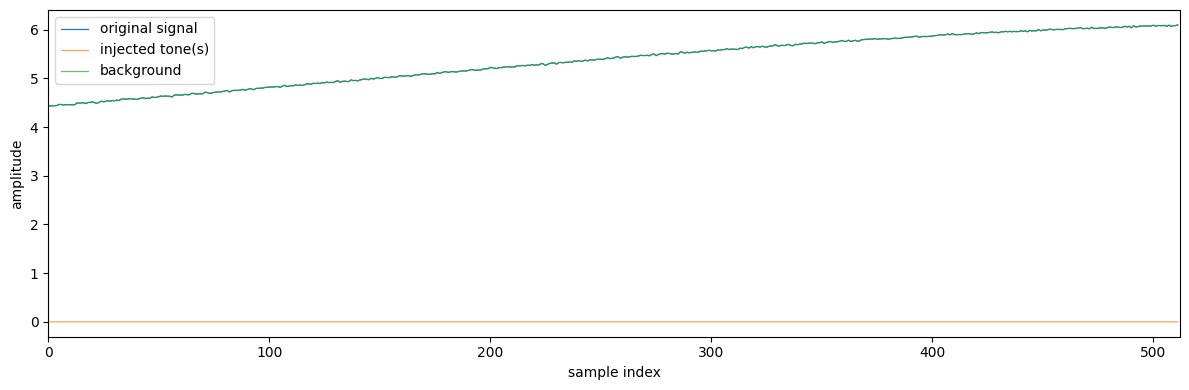

In [1136]:
# 2. Background signal recovery — exact (background + tone_sum == signal)
background = signal - tone_sum

# Sanity: max-abs deviation should be machine-epsilon
recon_err = np.max(np.abs((background + tone_sum) - signal))
print(f"reconstruction error (should be ~0): {recon_err:.2e}")

fig = plt.figure(figsize=(12, 4))
plt.plot(signal,    label='original signal',  lw=0.9)
plt.plot(tone_sum,  label='injected tone(s)', lw=0.9, alpha=0.7)
plt.plot(background, label='background',      lw=0.9, alpha=0.7)
plt.xlabel('sample index'); plt.ylabel('amplitude'); plt.legend()
plt.xlim(0, len(signal))
plt.tight_layout()
plt.savefig(OUT / 'signal_analysis.png', dpi=140, bbox_inches='tight')
plt.show()


In [1137]:
_, cap_bg = forward_capture(background[:CONTEXT_LEN]) 
# we feed the background signal to the model and capture the outputs of the layers in the cap_bg dictionary, 
# which we will use as a control to compare with the cap dictionary that contains the activations for the original signal with the injected tone.

# as well as before we filter the stages to keep only those that were actually captured in the cap_bg dictionary, since some layers might not be present in the model depending on its configuration.
REL_STAGES = ['input', 'pre_embed', 'post_embed', *[f"enc{k}" for k in range(N_ENC)], 
              *[f"dec{k}" for k in range(N_DEC)], "dec_out"]
REL_STAGES = [s for s in REL_STAGES if s in cap and s in cap_bg]
rel = [stage_dist(cap[s], cap_bg[s]) for s in REL_STAGES] 
xs = np.arange(len(REL_STAGES)); jmin = int(np.argmin(rel))

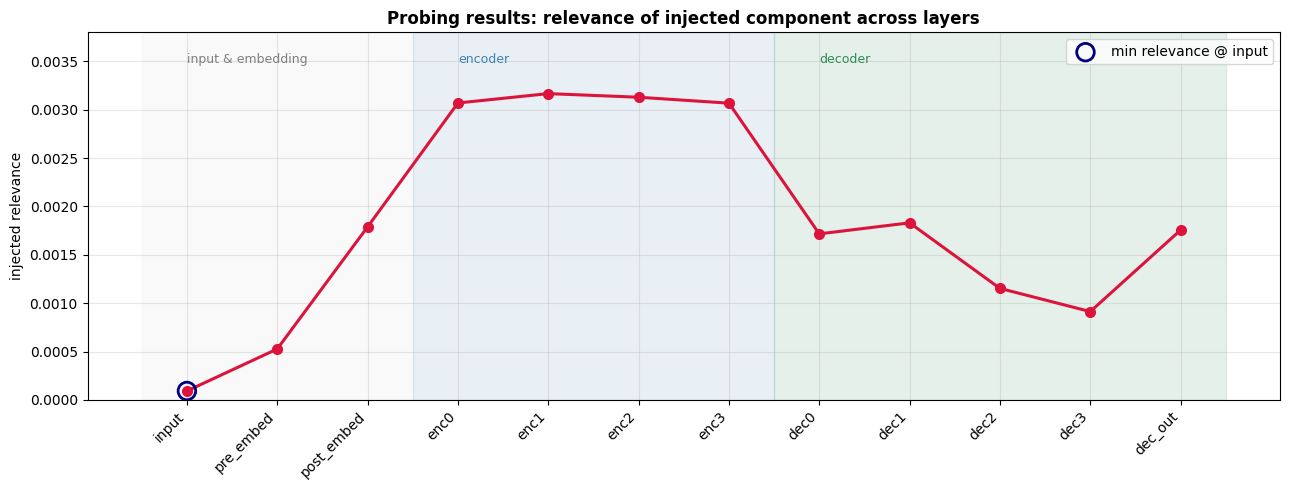

In [1138]:
fig, ax = plt.subplots(figsize=(13, 5))

enc0 = REL_STAGES.index("enc0") if "enc0" in REL_STAGES else None
dec0 = REL_STAGES.index("dec0") if "dec0" in REL_STAGES else None

ax.axvspan(0-0.5, (enc0 if enc0 is not None else len(REL_STAGES))-0.5, color="lightgray", alpha=.12)
ax.text(0, max(rel)*1.1, "input & embedding", color="gray", fontsize=9)
if enc0 is not None:
    ax.axvspan(enc0-0.5, dec0-0.5, color="steelblue", alpha=.12)
    ax.text(enc0, max(rel)*1.1, "encoder", color="steelblue", fontsize=9)
if dec0 is not None:
    ax.axvspan(dec0-0.5, len(REL_STAGES)-0.5, color="seagreen", alpha=.12)
    ax.text(dec0, max(rel)*1.1, "decoder", color="seagreen", fontsize=9)

ax.plot(xs, rel, "o-", color="crimson", lw=2.2, ms=7)
ax.scatter([jmin], [rel[jmin]], s=160, facecolors="none", edgecolors="navy", lw=2,
           zorder=5, label=f"min relevance @ {REL_STAGES[jmin]}")

ax.set_xticks(xs)
ax.set_ylim(0, max(rel)*1.2)
ax.set_xticklabels(REL_STAGES, rotation=45, ha="right")
ax.set_ylabel("injected relevance") # on y we have a relevance score that measures how much the activations of the layer are affected by the presence of the injected component, compared to the background signal where the component is not present. 
ax.set_title("Probing results: relevance of injected component across layers", fontweight="bold")
ax.legend()
ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(OUT/"PLT1_relevance_detector.png", dpi=140, bbox_inches="tight")
plt.show()

### 3.2 - Recoverability of information (SLD-MDL)

**What it measures**: how *linearly and compressibly* the injected tone(s) are encoded at
each stage, using the paper's prequential Minimum Description Length metric (Space Saving, SV).

A binary detection dataset is built: `bg + tone_sum` (present, label 1) vs `bg` (absent,
label 0) over N random backgrounds with **random phase per realisation** as nuisance.
A lightweight linear probe is trained sequentially (prequential); the total codelength vs
the uniform binary baseline gives:

    SV      = 1 - L_probe / L_uniform         ← task: true labels
    SV_ctrl = 1 - L_probe / L_uniform         ← control: shuffled labels

Because the control has no real signal, `SV_ctrl ≤ 0` (up to noise). The interpretable
quantity is the gap:

    selectivity = SV - SV_ctrl

Large positive gap = the tones are genuinely and linearly accessible at that stage.
`SV_ctrl ≈ 0` confirms no spurious memorisation.

**Why leakage-free**: the target is binary detection (present/absent), *not* the
frequencies themselves. Phase randomisation prevents the probe from using phase as a
shortcut. The control calibrates against any residual overfitting.

**Key limitation**: measures strictly *linear* decodability. A stage can physically carry
the tone's information in a nonlinear form and still show low SV — the SCPA detector
(Section 3.1) captures that orthogonal dimension.


In [1139]:
N_PAIR = 30 # number of pairs of samples (original vs background) to generate for the MDL probing.
# Each pair consists of the activations of a layer for the original signal with the injected tone (label 1) and the activations of the same layer for the background signal without the tone (label 0).
# Total number of samples will be 2*N_PAIR, since we have N_PAIR samples for each class (original vs background).

Hf = {s: [] for s in REL_STAGES} 
# we initialize a dictionary Hf to store the activations of the layers for all the samples we will generate. 
# The keys of Hf are the names of the layers in REL_STAGES and the values are lists that will contain the activations of those layers for each sample.

We construct a binary dataset over many random backgrounds:
  - class 0: background only (bg)
  - class 1: background + injected tone sum (bg + Σ tones)

Each tone instance uses **random phase per realisation** to remove alignment artifacts.
All samples are forwarded through the model and hidden representations are extracted at
each stage. For each stage, a linear classifier (logistic regression) is trained to
distinguish presence vs absence of the tones.

Performance is evaluated using a prequential MDL criterion, where predictive
probabilities are converted into code length:
  L = -log2 p(y|x)

The recoverability score is defined as:
  SV = 1 - L / L_uniform

**Critical**: `runRandomSignal` is called with `fs=FS` so the background signal lives on
the same sampling grid as our injected tones — otherwise `bg + tn` would mix grids.


In [1140]:
yb = []  # class 0 = background only, class 1 = background + injected tones

for i in range(N_PAIR):
    # 1. random background signal on the SAME sampling grid as our tones
    background = sg.runRandomSignal(
        l_min=CONTEXT_LEN, l_max=CONTEXT_LEN,
        fs=FS, seed=SEED + i,
    )

    # 2. build the injected tone sum with random phase per realisation
    m     = np.arange(len(background))
    t_sec = m / float(FS)
    tn = np.zeros(len(background))
    for info in INJECT_LIST:
        ph_rand = rngm.uniform(0, 2 * np.pi)  # random phase → not patch-aligned
        tn += info['amplitude'] * np.sin(2 * np.pi * info['freq_hz'] * t_sec + ph_rand)

    # 3. capture activations for both background and background+tones
    _, d0 = forward_capture(background)
    _, d1 = forward_capture(background + tn)

    for s in REL_STAGES:
        Hf[s].append(np.ravel(d0[s]))
        Hf[s].append(np.ravel(d1[s]))
    yb += [0, 1]

yb = np.array(yb)
Xb = {s: np.vstack(Hf[s]) for s in REL_STAGES}


In [1141]:
yc = rngm.permutation(yb) 
# shuffle the labels to create a control condition where the relationship between the activations and the 
# labels is broken, which will allow us to assess the significance of the relevance scores we compute later 
# by comparing them to this control condition.

In [1142]:
def mdl_codelength(X, y, K=5, n_pca=20):
    """
    Prequential MDL codelength for a binary classification dataset (X, y).

    Pipeline: StandardScaler -> PCA(n_components=n_pca) -> LogisticRegression.

    Without PCA, with ~60 samples and thousands of features (encoder hidden
    states are ~32*256=8192 dims), logistic regression severely overfits
    and SV becomes catastrophically negative (well below the [0, 1-1/K]
    theoretical range). PCA(20) projects all stages to a common, well-
    conditioned subspace so SV is interpretable and comparable across stages.
    """
    r = np.random.default_rng(SEED)
    idx = r.permutation(len(y))
    X, y = X[idx], y[idx]

    ch = np.array_split(np.arange(len(y)), K)
    L  = len(ch[0]) * 1.0  # first chunk: uniform 1-bit per binary example

    for k in tqdm.tqdm(range(1, K), desc='CV', leave=False):
        train_idx = np.concatenate(ch[:k])
        test_idx  = ch[k]

        # Cap PCA components by data shape (prevents sklearn errors)
        n_comp = max(2, min(n_pca, X.shape[1], len(train_idx) - 1))
        clf = make_pipeline(
            StandardScaler(),
            PCA(n_components=n_comp),
            LogisticRegression(max_iter=2000, solver='lbfgs'),
        )
        clf.fit(X[train_idx], y[train_idx])

        pred = clf.predict_proba(X[test_idx])
        prediction = pred[np.arange(len(test_idx)), y[test_idx]]
        L += -np.log2(np.clip(prediction, 1e-6, 1)).sum()

    return L


In [1143]:
# an SV measures how much a probe can compress the label information using the model’s representations.
SV  = {s: 1 - mdl_codelength(Xb[s], yb)/len(yb)*1.0 for s in REL_STAGES}
# SV is "Space Saving" and measures how much the activations of the layer can be compressed when using the true labels yb compared to a random permutation of the labels yc.
# We create a new dictionary SV where the keys are the same as in Xb and the values are the "Space Saving" scores computed as 1 minus the ratio of the MDL codelength of the dataset (Xb[s], yb) to the length of yb (Lu).


In [1144]:
SV_ctrl = {s: 1 - mdl_codelength(Xb[s], yc)/len(yb)*1.0 for s in REL_STAGES}
# SV_ctrl is the "Space Saving" score computed using the shuffled labels yc, which serves as a control condition to assess the significance of the SV scores computed with the true labels yb.
# We create a new dictionary SV_ctrl where the keys are the same as in Xb and the values are the "Space Saving" scores computed as 1 minus the ratio of the MDL codelength of the dataset (Xb[s], yc) to the length of yb (Lu), where yc is a random permutation of yb that breaks the relationship between the activations and the labels, allowing us to assess the significance of the SV scores by comparing them to this control condition.

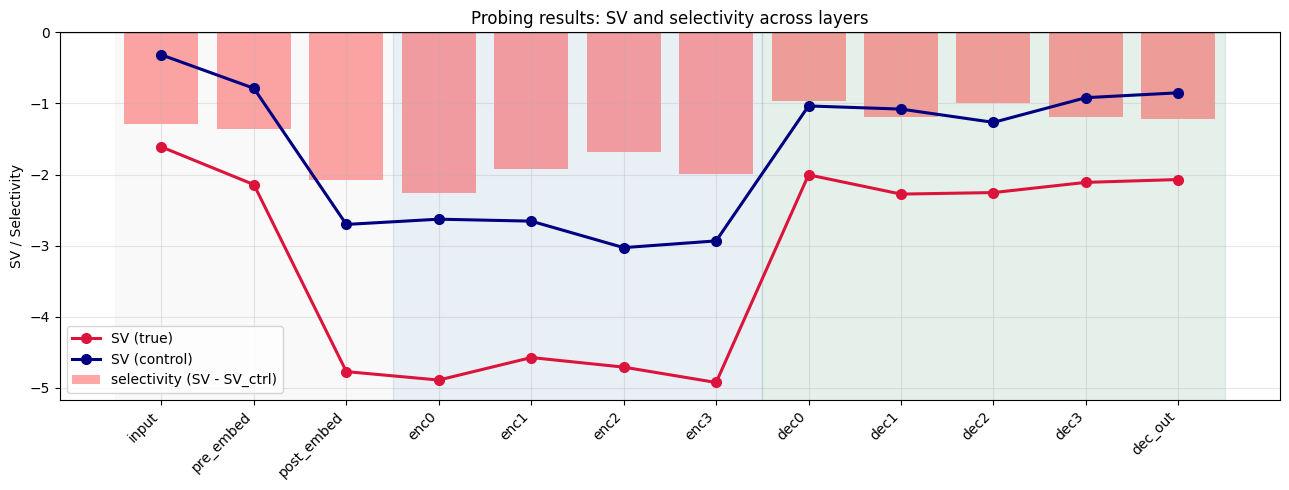

input      | selectivity=-1.2944 | NEG
pre_embed  | selectivity=-1.3541 | NEG
post_embed | selectivity=-2.0694 | NEG
enc0       | selectivity=-2.2616 | NEG
enc1       | selectivity=-1.9178 | NEG
enc2       | selectivity=-1.6800 | NEG
enc3       | selectivity=-1.9909 | NEG
dec0       | selectivity=-0.9685 | NEG
dec1       | selectivity=-1.1949 | NEG
dec2       | selectivity=-0.9872 | NEG
dec3       | selectivity=-1.1908 | NEG
dec_out    | selectivity=-1.2195 | NEG


In [1145]:
xs = np.arange(len(REL_STAGES))
selectivity = np.array([SV[s] - SV_ctrl[s] for s in REL_STAGES])
sv_vals = np.array([SV[s] for s in REL_STAGES])
sv_ctrl_vals = np.array([SV_ctrl[s] for s in REL_STAGES])

fig, ax = plt.subplots(figsize=(13, 5))

enc0 = REL_STAGES.index("enc0") if "enc0" in REL_STAGES else None
dec0 = REL_STAGES.index("dec0") if "dec0" in REL_STAGES else None
ax.axvspan(-0.5, (enc0 if enc0 is not None else len(REL_STAGES))-0.5,
           color="lightgray", alpha=.12)

if enc0 is not None:
    ax.axvspan(enc0-0.5, dec0-0.5, color="steelblue", alpha=.12)
if dec0 is not None:
    ax.axvspan(dec0-0.5, len(REL_STAGES)-0.5, color="seagreen", alpha=.12)

# --- SV curves ---
ax.plot(xs, sv_vals, "o-", color="crimson", lw=2.2, ms=7, label="SV (true)")
ax.plot(xs, sv_ctrl_vals, "o-", color="navy", lw=2.2, ms=7, label="SV (control)")

colors = ["green" if v > 0 else "red" for v in selectivity]
ax.bar(xs, selectivity, color=colors, alpha=0.35, label="selectivity (SV - SV_ctrl)")
ax.axhline(0, color="black", lw=1, alpha=0.6)
ax.set_xticks(xs)
ax.set_xticklabels(REL_STAGES, rotation=45, ha="right")
ax.set_title("Probing results: SV and selectivity across layers")
ax.set_ylabel("SV / Selectivity")

ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/"PLT2_SV_selectivity.png", dpi=140, bbox_inches="tight")
plt.show()

for s, v in zip(REL_STAGES, selectivity):
    sign = "POS" if v > 0 else ("ZERO" if abs(v) < 1e-6 else "NEG")
    print(f"{s:10s} | selectivity={v:.4f} | {sign}")

* SV high + selectivity positive
    → real encoded signal present
* SV high + selectivity ≈ 0
    → likely noise-fitting / no true structure
* SV low + control similar
    → no decodable information
* selectivity negative
    → pathological / overfit / instability in probe

## 4 - Round-trip: input vs forecast spectrum

In [1146]:
def spec(x, fs=None, P_=None, n=None):
    """
    Return (cpp_axis, magnitude) for a real signal x.
    
    Pass the SAME `n` to input and forecast so they share an identical
    bin grid -- required for a rigorous side-by-side spectrum comparison.
    """
    if fs is None: fs = FS
    if P_ is None: P_ = P
    x = np.asarray(x, float) - np.mean(x)
    if n is None:
        n = len(x)
    mag      = np.abs(np.fft.rfft(x, n=n))
    freqs_hz = np.fft.rfftfreq(n, d=1.0 / fs)
    cpp_axis = freqs_hz * P_ / fs   # convert to cycles-per-patch
    return cpp_axis, mag

def magnitude_at(x, freq_hz, fs=None, window='hann'):
    """
    Goertzel-style DFT magnitude at a single arbitrary frequency.
    Hann window by default to suppress spectral leakage for off-grid
    frequencies (verified: on-grid ~ε, off-grid ~1e-5 with Hann vs 4e-4 without).
    Returns the equivalent amplitude of a pure tone at freq_hz in x.
    """
    if fs is None: fs = FS
    x = np.asarray(x, float) - np.mean(x)
    N = len(x)
    w = np.hanning(N) if window == 'hann' else np.ones(N)
    n = np.arange(N)
    e = np.exp(-2j * np.pi * freq_hz * n / fs)
    return np.abs((x * w * e).sum()) / N * 2.0 / w.mean()


In [1147]:
forecast = pipeline.predict(torch.tensor(signal, dtype=torch.float32).unsqueeze(0))
pred  = forecast[0].median(dim=0).values.numpy()
preds = [forecast[0][i].numpy() for i in range(min(9, forecast.shape[1]))]

# FFT alignment: zero-pad both input and forecast to the SAME length so the
# frequency bin spacing is identical.  Choose the maximum to preserve resolution.
FFT_N = max(len(signal), len(pred))

In [1148]:
# ===================================================================
# Quantitative table — Hann-windowed exact-frequency magnitude
# ===================================================================
MAGN_FLOOR  = 1e-4                                 # numerical floor on |X_in|
PRED_NYQ_HZ = FS / 2.0
PRED_SAFE_HZ = 0.75 * PRED_NYQ_HZ * len(pred) / FFT_N  # safe for pred-length leakage

print(f"\nFFT_N = {FFT_N}, forecast length = {len(pred)}, "
      f"safe pred-side band: freq <= {PRED_SAFE_HZ:.1f} Hz "
      f"(cpp <= {PRED_SAFE_HZ * P / FS:.2f})\n")

print(f"{'freq (Hz)':>10s} {'cpp':>7s} {'|X_in|':>10s} {'|X_out|':>10s} "
      f"{'ratio (dB)':>11s}  flags")
print('-' * 74)
for info in INJECT_LIST:
    m_in_v  = magnitude_at(signal, info['freq_hz'])
    m_out_v = magnitude_at(pred,   info['freq_hz'])
    flags = []
    if info['is_blind']:                     flags.append('BLIND')
    if info['freq_hz'] > PRED_SAFE_HZ:       flags.append('near-Nyq')
    if m_in_v < MAGN_FLOOR:
        ratio_str = f"{'NA':>11s}"
        flags.append('low |X_in|')
    else:
        ratio_db = 20 * np.log10((m_out_v + 1e-12) / m_in_v)
        ratio_str = f"{ratio_db:>+11.2f}"
    print(f"{info['freq_hz']:>10.4g} {info['cpp']:>7.3f} "
          f"{m_in_v:>10.4g} {m_out_v:>10.4g} {ratio_str}  {', '.join(flags) or 'visible'}")

print("\nratio (dB) < 0  →  tone attenuated in forecast.")
print("ratio (dB) > 0  →  tone amplified (typical for integer cpp).")


FFT_N = 512, forecast length = 64, safe pred-side band: freq <= 12.0 Hz (cpp <= 0.75)

 freq (Hz)     cpp     |X_in|    |X_out|  ratio (dB)  flags
--------------------------------------------------------------------------
        64   4.000  0.0002032   0.001561      +17.71  BLIND, near-Nyq

ratio (dB) < 0  →  tone attenuated in forecast.
ratio (dB) > 0  →  tone amplified (typical for integer cpp).


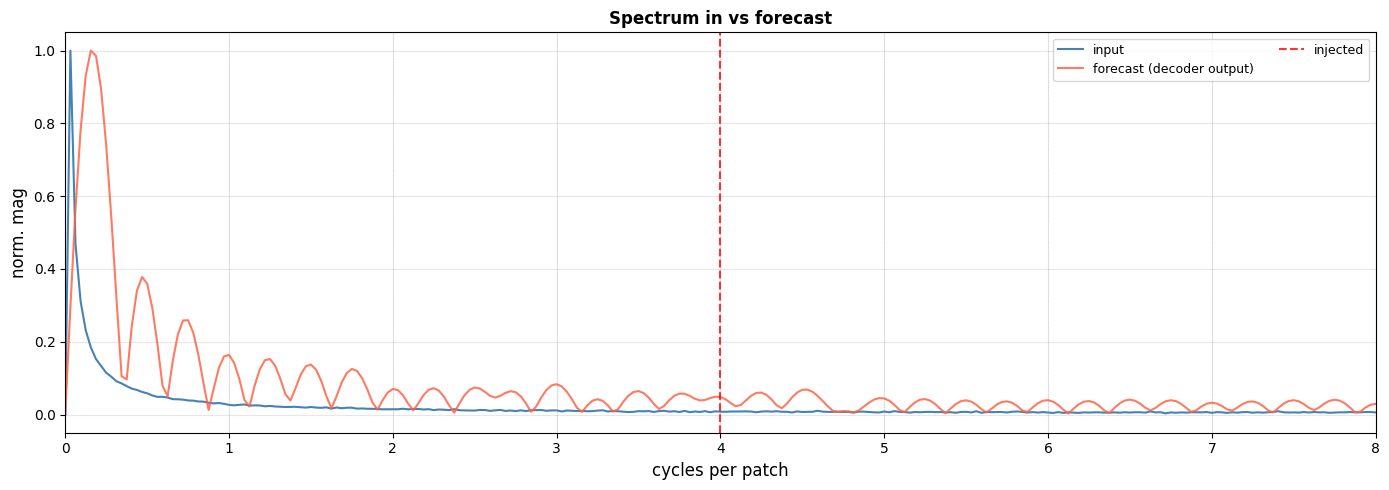

In [1149]:
fig, ax = plt.subplots(figsize=(14, 5))

cpp_in,  m_in  = spec(signal, fs=FS, P_=P, n=FFT_N)
cpp_out, m_out = spec(pred,   fs=FS, P_=P, n=FFT_N)

ax.plot(cpp_in,  m_in  / (m_in.max()  + 1e-12), color='steelblue', lw=1.5, label='input')
ax.plot(cpp_out, m_out / (m_out.max() + 1e-12), color='tomato',     lw=1.5, alpha=0.85,
        label='forecast (decoder output)')

# ALL injected tone markers (FIX: previously only one was drawn)
for info in INJECT_LIST:
    color  = 'red'   if info['is_blind'] else 'green'
    lstyle = '--'    if info['is_blind'] else ':'
    ax.axvline(info['cpp'], color=color, ls=lstyle, alpha=0.8, lw=1.5,
               label=f"injected")

# Integer-cpp grid (the theoretical blind-spot locations)
for k in range(0, P // 2 + 1):
    ax.axvline(k, color='grey', ls=':', alpha=0.20, lw=0.7)

ax.set_xlim(0, P // 2)
ax.set_xlabel('cycles per patch', fontsize=12)
ax.set_ylabel('norm. mag', fontsize=12)
ax.set_title('Spectrum in vs forecast', fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'PLT3.1_roundtrip.png', dpi=140, bbox_inches='tight')
plt.show()


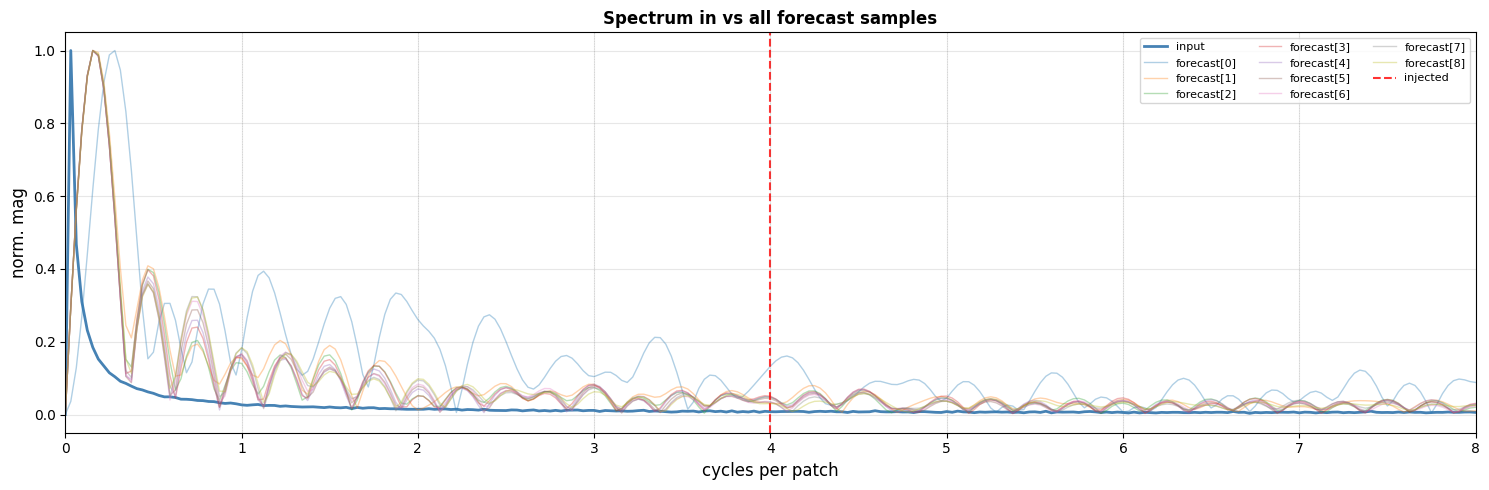

In [1150]:
fig, ax = plt.subplots(figsize=(15, 5))

cpp_in, m_in = spec(signal, fs=FS, P_=P, n=FFT_N)
ax.plot(cpp_in, m_in / (m_in.max() + 1e-12), color='steelblue', lw=2, label='input')

for i, pred_s in enumerate(preds):
    cpp_o, m_o = spec(pred_s, fs=FS, P_=P, n=FFT_N)
    ax.plot(cpp_o, m_o / (m_o.max() + 1e-12), alpha=0.35, lw=1, label=f'forecast[{i}]')

for info in INJECT_LIST:
    color  = 'red' if info['is_blind'] else 'green'
    lstyle = '--'  if info['is_blind'] else ':'
    ax.axvline(info['cpp'], color=color, ls=lstyle, alpha=0.8, lw=1.5,
               label=f"injected")

for k in range(0, P // 2 + 1):
    ax.axvline(k, color='grey', ls=':', alpha=0.20, lw=0.7)

ax.set_xlim(0, P // 2)
ax.set_xlabel('cycles per patch', fontsize=12)
ax.set_ylabel('norm. mag', fontsize=12)
ax.set_title('Spectrum in vs all forecast samples', fontweight='bold')
ax.legend(ncol=3, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'PLT3.2_roundtrip_samples.png', dpi=140, bbox_inches='tight')
plt.show()
